In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
df = pd.read_csv("C:/Users/muthi/OneDrive/HPP/train.csv")

In [13]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
df.shape

(1460, 81)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [16]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [17]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [18]:
X = df[['OverallQual',
        'GrLivArea',
        'GarageCars',
        'TotalBsmtSF']]

y = df['SalePrice']

In [19]:
X.isnull().sum()

OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
dtype: int64

In [20]:
X = X.fillna(X.mean())

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 25446.054739212446


In [26]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE =", rmse)

RMSE = 40036.418664060206


In [27]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = 0.7910239048318478


In [28]:
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
892,154500,143522.478557
1105,325000,288596.453556
413,115000,136156.554463
522,159000,187027.687043
1036,315500,293501.054731
614,75500,45499.086644
218,311500,217353.745011
1160,146000,173893.900108
649,84500,45499.086644
887,135500,126762.874126


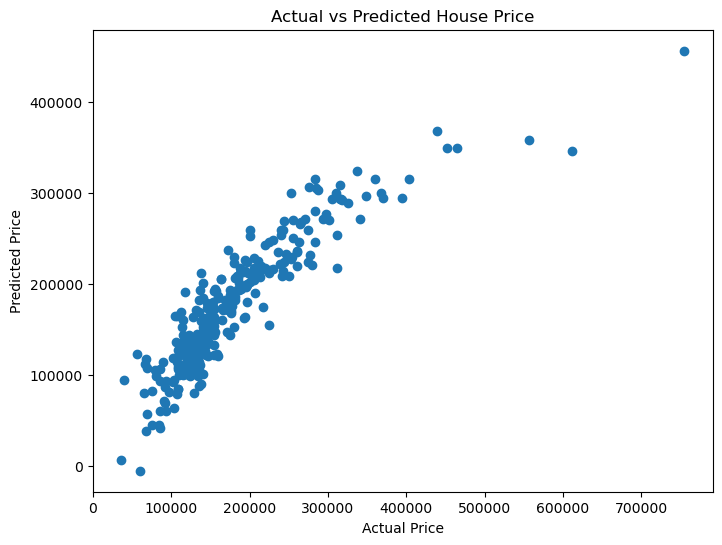

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

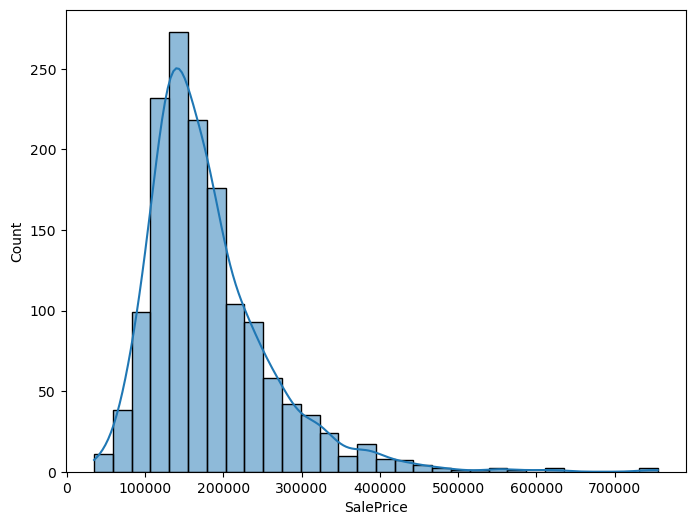

In [30]:
plt.figure(figsize=(8,6))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.show()

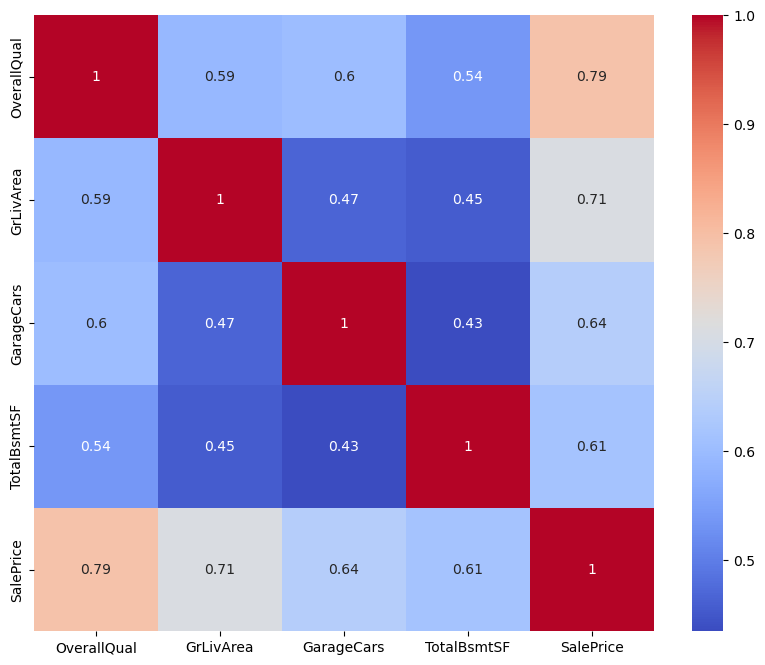

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['OverallQual',
                'GrLivArea',
                'GarageCars',
                'TotalBsmtSF',
                'SalePrice']].corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [34]:
new_house = pd.DataFrame({
    'OverallQual':[7],
    'GrLivArea':[1800],
    'GarageCars':[2],
    'TotalBsmtSF':[900]
})

predicted_price = model.predict(new_house)

print("Predicted House Price =", predicted_price[0])

Predicted House Price = 213660.29433563232


In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [37]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [38]:
rf_pred = rf_model.predict(X_test)

In [39]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("MAE =", mae_rf)
print("RMSE =", rmse_rf)
print("R2 Score =", r2_rf)

MAE = 20173.133639379743
RMSE = 30020.31095101346
R2 Score = 0.882505770256408


In [40]:
print("Linear Regression R2 Score =", r2)

print("Random Forest R2 Score =", r2_rf)

Linear Regression R2 Score = 0.7910239048318478
Random Forest R2 Score = 0.882505770256408


In [41]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values()

GarageCars     0.041643
TotalBsmtSF    0.137533
GrLivArea      0.230173
OverallQual    0.590650
dtype: float64

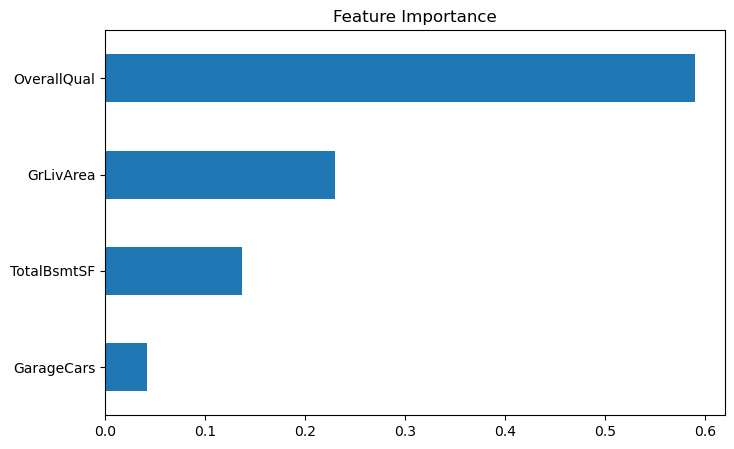

In [42]:
plt.figure(figsize=(8,5))

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")

plt.show()

In [43]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': rf_pred
})

comparison.head(10)

,Actual Price,Predicted Price
892,154500,136688.000000
1105,325000,322656.840000
413,115000,140446.500000
522,159000,175735.000000
1036,315500,299216.130000
614,75500,76685.000000
218,311500,204088.000000
1160,146000,153995.603333
649,84500,76685.000000
887,135500,116771.000000


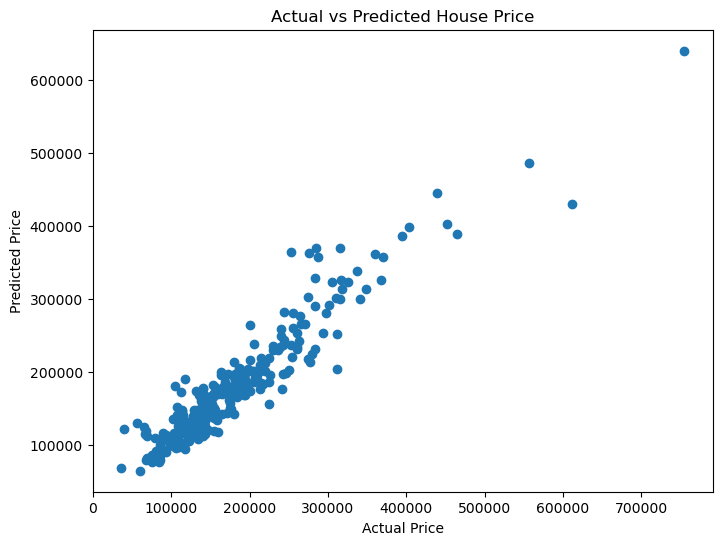

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.show()

In [45]:
errors = y_test - rf_pred

errors.head()

892     17812.00
1105     2343.16
413    -25446.50
522    -16735.00
1036    16283.87
Name: SalePrice, dtype: float64

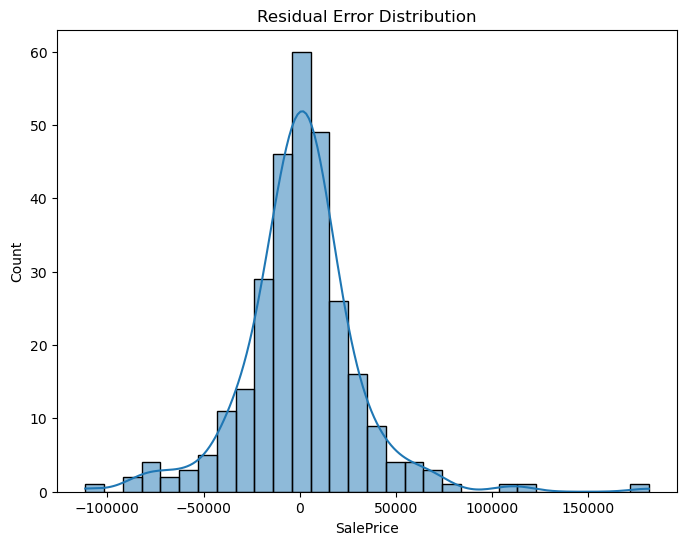

In [46]:
plt.figure(figsize=(8,6))

sns.histplot(errors, bins=30, kde=True)

plt.title("Residual Error Distribution")

plt.show()

In [47]:
import pickle

pickle.dump(rf_model, open("house_price_model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [48]:
loaded_model = pickle.load(open("house_price_model.pkl", "rb"))

In [49]:
new_house = pd.DataFrame({
    'OverallQual':[8],
    'GrLivArea':[2000],
    'GarageCars':[2],
    'TotalBsmtSF':[1000]
})

prediction = loaded_model.predict(new_house)

print("Predicted House Price =", prediction[0])

Predicted House Price = 255801.75
